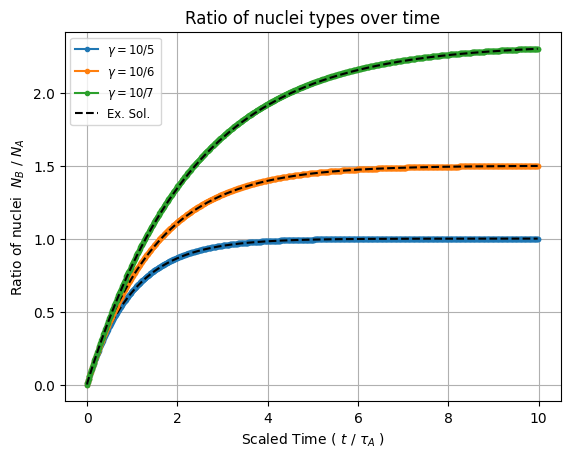

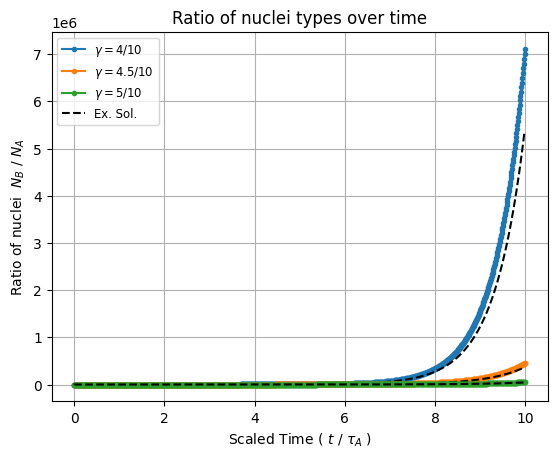

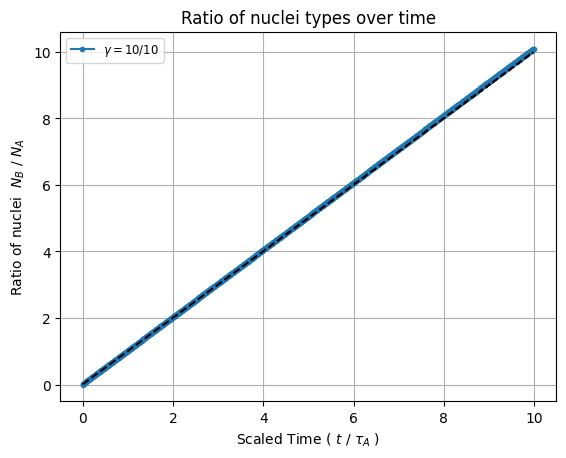

In [84]:
import numpy as np
import matplotlib.pyplot as plt


def A_prime(A,t,taua):
    value = -A[t] / taua
    return value

def B_prime(A,B,t,taua,taub):
    value = (A[t] / taua) - (B[t] / taub)
    return value


def Euler(taua,taub,max_time,dt):
    A_values = [1]
    B_values = [0]
    time = [0]
    t=0
    while t*dt < max_time:
        A_val = A_values[t]+(A_prime(A_values,t,taua)*dt)
        B_val = B_values[t]+(B_prime(A_values,B_values,t,taua,taub)*dt)
        A_values.append(A_val)
        B_values.append(B_val)
        time.append(t*dt)
        t+=1
    A_array = np.array(A_values)
    B_array = np.array(B_values)
    ratio = B_array / A_array
    scaled_time = [t / t_a for t in time]
    return np.array(scaled_time), ratio


def Analytic(time, ta, tb):
    A = np.exp(-time/ta)
    # handle case ta == tb by using a small offset to avoid division by zero
    if np.isclose(ta, tb):
        eps = 1e-12
        ta = ta + eps
    B = (tb/(ta - tb))*(np.exp(-time/ta) - np.exp(-time/tb))
    ratio = B / A
    return ratio

t_a = 10
t_b = 5
dt = 0.1
max_time = 100


## Analysis ##

time = np.arange(0, max_time, dt)
#######
# # ta > tb

# Ratio 1
scaled_time, ratio = Euler(10, 5, max_time, dt)
plt.plot(scaled_time,ratio,label=r"$\gamma=10/5$",linewidth=1.5, color='tab:blue', marker='o', markersize=3)
plt.plot(scaled_time[:-1],Analytic(time, 10, 5),'--', color='k',linewidth=1.5)
# Ratio 2
scaled_time, ratio = Euler(10, 6, max_time, dt)
plt.plot(scaled_time,ratio,label=r"$\gamma=10/6$",linewidth=1.5, color='tab:orange', marker='o', markersize=3)
plt.plot(scaled_time[:-1],Analytic(time, 10, 6),'--', color='k',linewidth=1.5)
# Ratio 3
scaled_time, ratio = Euler(10, 7, max_time, dt)
plt.plot(scaled_time,ratio,label=r"$\gamma=10/7$",linewidth=1.5, color='tab:green', marker='o', markersize=3)
plt.plot(scaled_time[:-1],Analytic(time, 10, 7),'--',label="Ex. Sol.", color='k',linewidth=1.5)

plt.xlabel(r"Scaled Time ( $t$ / $\tau_A$ )")
plt.ylabel(r"Ratio of nuclei  $N_B$ / $N_A$")
plt.title("Ratio of nuclei types over time")
plt.grid(True)
plt.legend(fontsize='small')



#####################
# # tb > ta
plt.figure()
scaled_time, ratio = Euler(4, 10, max_time, dt)
plt.plot(scaled_time,ratio,label=r"$\gamma=4/10$",linewidth=1.5, color='tab:blue', marker='o', markersize=3)
plt.plot(scaled_time[:-1],Analytic(time, 4, 10),'--', color='k',linewidth=1.5)


scaled_time, ratio = Euler(4.5, 10, max_time, dt)
plt.plot(scaled_time,ratio,label=r"$\gamma=4.5/10$",linewidth=1.5, color='tab:orange', marker='o', markersize=3)
plt.plot(scaled_time[:-1],Analytic(time, 4.5, 10),'--', color='k',linewidth=1.5)

scaled_time, ratio = Euler(5, 10, max_time, dt)
plt.plot(scaled_time,ratio,label=r"$\gamma=5/10$",linewidth=1.5, color='tab:green', marker='o', markersize=3)
plt.plot(scaled_time[:-1],Analytic(time, 5, 10),'--',label="Ex. Sol.", color='k',linewidth=1.5)

plt.xlabel(r"Scaled Time ( $t$ / $\tau_A$ )")
plt.ylabel(r"Ratio of nuclei  $N_B$ / $N_A$")
plt.title("Ratio of nuclei types over time")
plt.grid(True)
plt.legend(fontsize='small')

#############
# ta = tb
plt.figure()
scaled_time, ratio = Euler(10, 10, max_time, dt)
plt.plot(scaled_time,ratio,label=r"$\gamma=10/10$",linewidth=1.5, color='tab:blue', marker='o', markersize=3)
plt.plot(scaled_time[:-1],Analytic(time, 10, 10),'--', color='k',linewidth=1.5)
plt.xlabel(r"Scaled Time ( $t$ / $\tau_A$ )")
plt.ylabel(r"Ratio of nuclei  $N_B$ / $N_A$")
plt.title("Ratio of nuclei types over time")
plt.grid(True)
plt.legend(fontsize='small')


##########################################################
plt.show()
